In [1]:
#!/Users/Lucas/anaconda2/bin/python

from astropy.time import Time as aTime
from astropy.coordinates import SkyCoord
from astropy import units as u
import datetime, difflib, numpy as np
from numpy import cos, sin, tan, pi
import pdb
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt

In [33]:
class Maser:
    kind = 'maser' 
    def __init__(self, name, ra, dec, vel, flux, alias):
        self.name  = name  
        self.ra    = ra
        self.dec   = dec
        self.vel   = float(vel)
        self.cflux = float(flux)
        self.alias = alias

masers = np.array([
    ['G287.371+0.644',	'10:48:04',	'-58:27:01',	-1.9,	21.9,	's013'],
    #['G291.274-0.709',	'11:11:53',	'-61:18:24',	-30.7,	10.7,	's025'],
    #['G299.772-0.005',	'12:23:49',	'-62:42:25',	-6.7,	12.3,	's026'],
    #['G305.200+0.019',	'13:11:17',	'-62:45:55',	-32,	8.6,    's027'],
    #['G318.948-0.196',	'15:00:55',	'-58:58:52',	-36.3,	12.5,	's028'],
    #['G329.407-0.459',	'16:03:33',	'-53:09:27',	-66.6,	7.3,	's029'],
    #['G338.920+0.550',	'16:40:34',	'-45:42:07',	-61.3,	9.3,	's030'],
    #['G337.920-0.456',	'16:41:06',	'-47:07:03',	-38.6,	12.7,	's021'],
    ['G340.785-0.096',  '16:50:15.8','-44:42:26.3',-100,40,'s032'],
    ['G352.630-1.067',	'17:31:14',	'-35:44:09',	-3.3,	17.6,	's024']
     ])


tt = [
     ['Dec 16, 2023','Dec 26, 2023','Jan 2, 2024','May 29, 2024','Jun 2, 2024','Jun 8, 2024','Jun 19, 2024','Dec 15, 2024','Dec 22, 2024','Dec 31, 2024']
     #,['Dec 21, 2024','Dec 29, 2024']
     #,['Jan 4, 2025','Feb 22, 2025']
     #,['Dec 30, 2024','Jan 5, 2025']
     #,['Feb 23, 2025','Mar 16, 2025']
     #,['Mar 22, 2025','Apr 5, 2025']
     #,['Mar 23, 2025','Apr 6, 2025']
     #,['Mar 29, 2025','Apr 13, 2025']
     ,['Sep 21, 2024','Sep 29, 2024','May 6, 2025']
     ,['Jan 26, 2024','Feb 13, 2024','Mar 23, 2024','Aug 3, 2024','Aug 24, 2024','Aug 31, 2024','Sep 8, 2024','Feb 21, 2025','May 4, 2025']
     ]



def parpropmot(p,t,t_r,ra,dec):
    X  = cos(2*pi*(t-0.22))
    Y  = sin(2*pi*(t-0.22))*cos(23.4/180.*pi)
    Z  = sin(2*pi*(t-0.22))*sin(23.4/180.*pi)
    Te = 1.0 + 0.0167*sin(2*pi*(t-0.257))
    xm = p[0]*Te*(Y*cos(ra) - X*sin(ra)) + p[1]*(t - t_r)
    ym = p[0]*Te*(Z*cos(dec) - X*cos(ra)*sin(dec) - Y*sin(ra)*sin(dec)) + p[2]*(t - t_r)
    return np.array([xm, ym])


In [34]:
c = SkyCoord(masers[1][1],masers[1][2],unit=(u.hourangle,u.degree))
t = np.arange(-1.1,.5,0.001)+2025. #- aTime.now().decimalyear%1 
x,y = parpropmot([1.0,0,0],t,0,c.ra.rad,c.dec.rad)

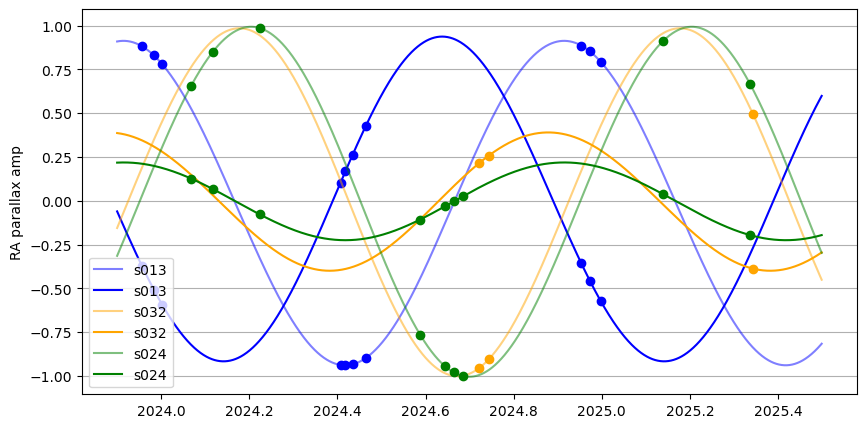

In [38]:
fig, ax = plt.subplots(1,figsize=(10,5))

cols = ['blue','orange','green','red','purple','brown','pink','gray','olive','black']

#ax.hlines(y=0,xmin=-0.25,xmax=1.25,color='k')
for i in range(len(masers)):
    c = SkyCoord(masers[i][1],masers[i][2],unit=(u.hourangle,u.degree))
    x ,y  = parpropmot([1.0,0,0],t ,0,c.ra.rad,c.dec.rad)
    ts = np.array([aTime(datetime.datetime.strptime(s,'%b %d, %Y')).decimalyear for s in tt[i]])
    #ts[ts > 0.5]+=-1.0
    x0 ,y0  = parpropmot([1.0,0,0],ts ,0,c.ra.rad,c.dec.rad)
    ax.plot(t , x, label=masers[i][-1],c=cols[i],alpha=0.5)
    ax.plot(t , y, label=masers[i][-1],c=cols[i])
    ax.plot(ts ,x0 ,'o',c=cols[i])
    ax.plot(ts ,y0 ,'o',c=cols[i])
    #ax.plot(t , -y, c=cols[i], ls='--',alpha=0.5)
    #ax.plot(ts ,-y0 ,'o',c=cols[i],alpha=0.5)
#ax.set_yticks([-1,-.75,-.5,-0.25,0,.25,.5,.75,1])
#ax.set_xticks(np.arange(-1,13,1)*0.083)
#ax.set_xticklabels(['Dec','Jan','Feb','Mar','Apr','May','Jun','Jul','Sep','Oct','Nov','Dec','Jan','Feb'])
ax.grid(True,axis='y')
ax.set_ylabel('RA parallax amp')
#ax.set_xlim([0.1,.4]);
#ax.set_ylim([.0,1.]);
ax.legend();

In [107]:
aTime(datetime.datetime.strptime(tt[0][0],'%b %d, %Y')).decimalyear

2024.9535519125684

In [98]:
tt[0][0]

'Dec 15, 2024'